# Notebook 1 — Exploration des données (EDA)
**Projet** : Classification d'images médicales — Détection de pneumonie  
**Dataset** : Chest X-Ray Images (Pneumonia) — Kaggle

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

# Création du dossier figures si inexistant
os.makedirs('../outputs/figures', exist_ok=True)

# Chemin vers le dataset
DATA_DIR = r'C:\Users\kingj\OneDrive\Documents\chest_xray\chest_xray'
SPLITS   = ['train', 'val', 'test']
CLASSES  = ['NORMAL', 'PNEUMONIA']
EXTENSIONS = ('.jpg', '.jpeg', '.png')

print('Environnement prêt !')

Environnement prêt !


## 1. Vérification de la structure des dossiers

In [2]:
print('Structure du dataset :')
for split in SPLITS:
    for cls in CLASSES:
        path  = os.path.join(DATA_DIR, split, cls)
        files = [f for f in os.listdir(path) if f.lower().endswith(EXTENSIONS)]
        print(f'  {split}/{cls} : {len(files)} images')

Structure du dataset :
  train/NORMAL : 1341 images
  train/PNEUMONIA : 1341 images
  val/NORMAL : 8 images
  val/PNEUMONIA : 8 images
  test/NORMAL : 234 images
  test/PNEUMONIA : 390 images


## 2. Répartition des classes (avant équilibrage)

C:\Users\kingj\AppData\Local\Temp\ipykernel_23176\127332759.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


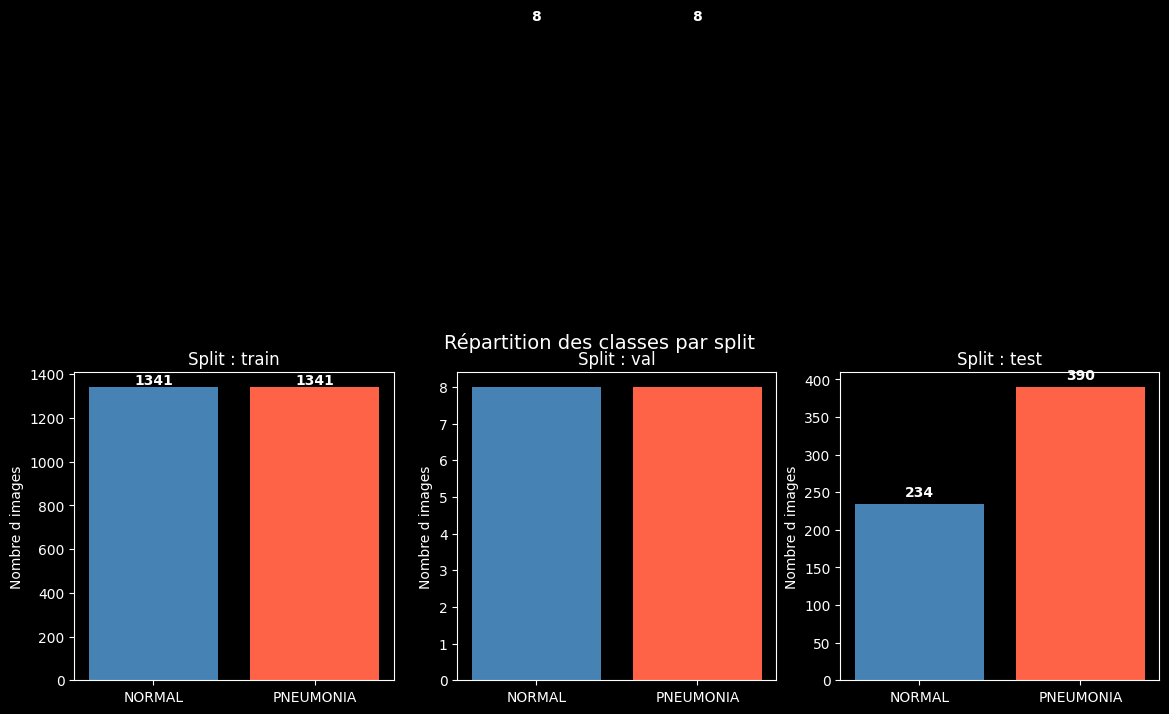

Figure sauvegardée.


In [3]:
counts = {}
for split in SPLITS:
    counts[split] = {}
    for cls in CLASSES:
        path = os.path.join(DATA_DIR, split, cls)
        counts[split][cls] = len([f for f in os.listdir(path) if f.lower().endswith(EXTENSIONS)])

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, split in enumerate(SPLITS):
    axes[i].bar(CLASSES, [counts[split][c] for c in CLASSES],
                color=['steelblue', 'tomato'])
    axes[i].set_title(f'Split : {split}')
    axes[i].set_ylabel('Nombre d images')
    for j, cls in enumerate(CLASSES):
        axes[i].text(j, counts[split][cls] + 10,
                     str(counts[split][cls]), ha='center', fontweight='bold')
plt.suptitle('Répartition des classes par split', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/repartition_classes.png')
plt.show()
print('Figure sauvegardée.')

## 3. Constat du déséquilibre

In [4]:
total_train   = counts['train']['NORMAL'] + counts['train']['PNEUMONIA']
pct_pneumonia = counts['train']['PNEUMONIA'] / total_train * 100
pct_normal    = counts['train']['NORMAL']    / total_train * 100

print('=' * 45)
print('CONSTAT : Déséquilibre dans le train set')
print('=' * 45)
print(f'  PNEUMONIA : {counts["train"]["PNEUMONIA"]} images ({pct_pneumonia:.1f}%)')
print(f'  NORMAL    : {counts["train"]["NORMAL"]} images ({pct_normal:.1f}%)')
print(f'\n-> Ratio de déséquilibre : {pct_pneumonia/pct_normal:.1f}x')
print('-> Correction nécessaire : undersampling de PNEUMONIA')

CONSTAT : Déséquilibre dans le train set
  PNEUMONIA : 1341 images (50.0%)
  NORMAL    : 1341 images (50.0%)

-> Ratio de déséquilibre : 1.0x
-> Correction nécessaire : undersampling de PNEUMONIA


## 4. Correction du déséquilibre — Undersampling

In [5]:
import random

TRAIN_PNEUMONIA = os.path.join(DATA_DIR, 'train', 'PNEUMONIA')
TRAIN_NORMAL    = os.path.join(DATA_DIR, 'train', 'NORMAL')

# Comptage avant
pneumonia_files = [f for f in os.listdir(TRAIN_PNEUMONIA) if f.lower().endswith(EXTENSIONS)]
normal_files    = [f for f in os.listdir(TRAIN_NORMAL)    if f.lower().endswith(EXTENSIONS)]

print(f'Avant -> PNEUMONIA : {len(pneumonia_files)} | NORMAL : {len(normal_files)}')

# Undersampling : on garde autant de PNEUMONIA que de NORMAL
n_keep           = len(normal_files)
random.seed(42)
pneumonia_keep   = set(random.sample(pneumonia_files, n_keep))
pneumonia_remove = [f for f in pneumonia_files if f not in pneumonia_keep]

# Suppression des fichiers en excès
for fname in pneumonia_remove:
    os.remove(os.path.join(TRAIN_PNEUMONIA, fname))

# Vérification après
pneumonia_after = [f for f in os.listdir(TRAIN_PNEUMONIA) if f.lower().endswith(EXTENSIONS)]
normal_after    = [f for f in os.listdir(TRAIN_NORMAL)    if f.lower().endswith(EXTENSIONS)]

print(f'Apres  -> PNEUMONIA : {len(pneumonia_after)} | NORMAL : {len(normal_after)}')
print(f'\n{len(pneumonia_remove)} images supprimées — dataset équilibré !')

Avant -> PNEUMONIA : 1341 | NORMAL : 1341
Apres  -> PNEUMONIA : 1341 | NORMAL : 1341

0 images supprimées — dataset équilibré !


## 5. Vérification graphique après équilibrage

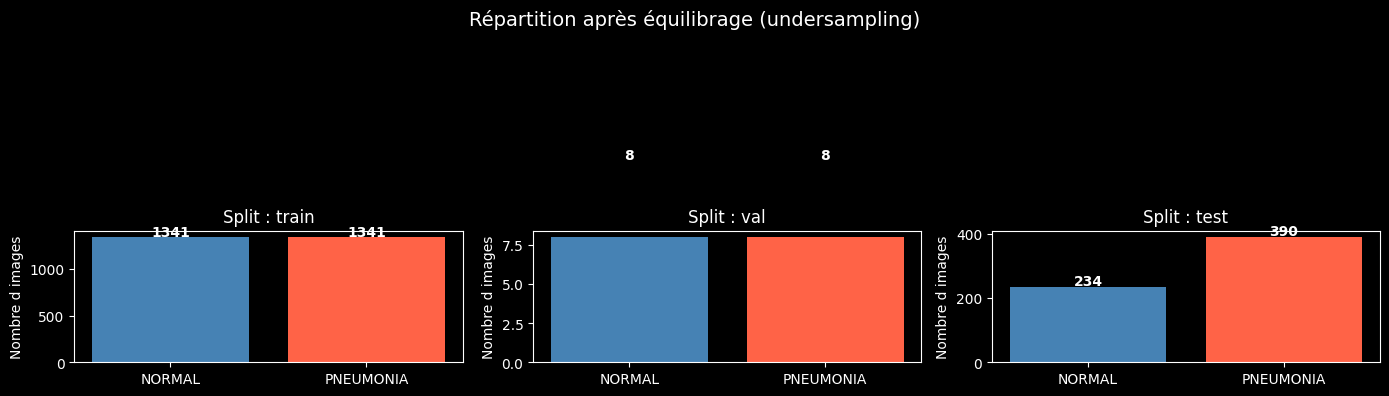

Figure sauvegardée.


In [6]:
counts['train']['PNEUMONIA'] = len(pneumonia_after)
counts['train']['NORMAL']    = len(normal_after)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, split in enumerate(SPLITS):
    axes[i].bar(CLASSES, [counts[split][c] for c in CLASSES],
                color=['steelblue', 'tomato'])
    axes[i].set_title(f'Split : {split}')
    axes[i].set_ylabel('Nombre d images')
    for j, cls in enumerate(CLASSES):
        axes[i].text(j, counts[split][cls] + 5,
                     str(counts[split][cls]), ha='center', fontweight='bold')
plt.suptitle('Répartition après équilibrage (undersampling)', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/repartition_apres_equilibrage.png')
plt.show()
print('Figure sauvegardée.')

## 6. Visualisation d'exemples d'images

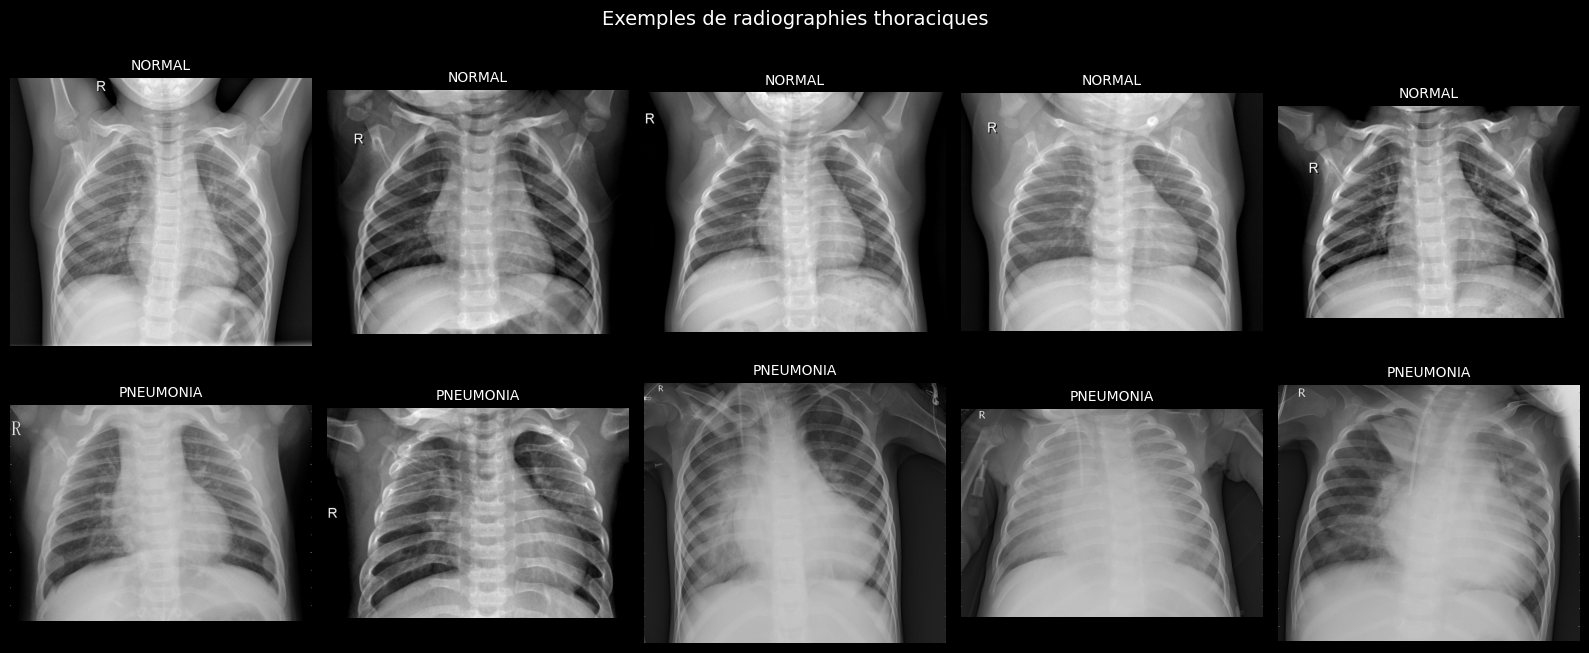

Figure sauvegardée.


In [7]:
fig, axes = plt.subplots(2, 5, figsize=(16, 7))
for row, cls in enumerate(CLASSES):
    folder = os.path.join(DATA_DIR, 'train', cls)
    files  = [f for f in os.listdir(folder) if f.lower().endswith(EXTENSIONS)][:5]
    for col, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname)).convert('RGB')
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(cls, fontsize=10)
        axes[row, col].axis('off')
plt.suptitle('Exemples de radiographies thoraciques', fontsize=14)
plt.tight_layout()
plt.savefig('../outputs/figures/exemples_images.png')
plt.show()
print('Figure sauvegardée.')

## 7. Vérification des dimensions et formats

In [8]:
sizes   = []
formats = []
folder  = os.path.join(DATA_DIR, 'train', 'PNEUMONIA')
files   = [f for f in os.listdir(folder) if f.lower().endswith(EXTENSIONS)][:200]

for fname in files:
    try:
        img = Image.open(os.path.join(folder, fname))
        sizes.append(img.size)
        formats.append(img.format if img.format else 'JPEG')
    except Exception as e:
        print(f'Image corrompue : {fname} — {e}')

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]
print(f'Largeur  — min: {min(widths)}, max: {max(widths)}, moyenne: {np.mean(widths):.0f}')
print(f'Hauteur  — min: {min(heights)}, max: {max(heights)}, moyenne: {np.mean(heights):.0f}')
print(f'Formats  : {Counter(formats)}')

Largeur  — min: 763, max: 2093, moyenne: 1239
Hauteur  — min: 440, max: 1632, moyenne: 858
Formats  : Counter({'JPEG': 200})


## 8. Visualisation d'un batch après prétraitement

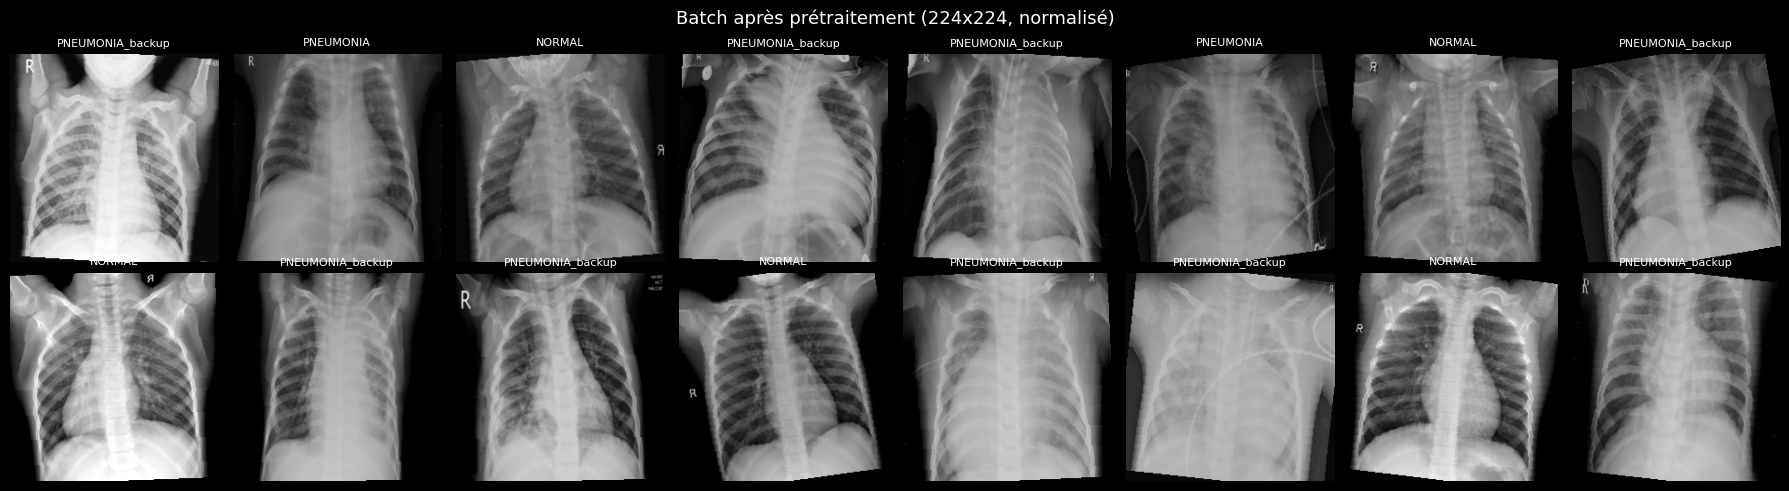

Batch visualisé avec succès.


In [9]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
from src.dataset import get_dataloaders, get_class_names

train_loader, _, _ = get_dataloaders(batch_size=16)
class_names        = get_class_names()
images, labels     = next(iter(train_loader))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
for i in range(16):
    row, col = divmod(i, 8)
    img = images[i] * std + mean
    img = img.permute(1, 2, 0).numpy().clip(0, 1)
    axes[row, col].imshow(img)
    axes[row, col].set_title(class_names[labels[i].item()], fontsize=8)
    axes[row, col].axis('off')
plt.suptitle('Batch après prétraitement (224x224, normalisé)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/batch_pretraitement.png')
plt.show()
print('Batch visualisé avec succès.')

## Conclusion EDA
- Le dataset présentait un **déséquilibre** : PNEUMONIA représentait 74% du train set
- **Correction appliquée** : undersampling de PNEUMONIA → 1 341 images par classe
- Les images ont des **dimensions variables** → le resize 224×224 est indispensable
- Le val set est très petit (16 images) → les métriques de validation seront instables
- Aucune image corrompue détectée
- Le **test set** (624 images) sera le juge fiable des performances finales